In [74]:
import json
import random
import csv
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [75]:
all_data = json.load(open('./raw_data.json', 'r'))
for row in all_data:
    for item in row['items']:
        del item['paramoji']['choices']
        item['paramoji']['value'] = np.round(item['paramoji']['value'],4).tolist()
f = open('raw_data_fec.json','w')
f.write(json.dumps(all_data))
f.close()

In [76]:
all_data = json.load(open('./raw_data_fec.json', 'r'))

In [77]:
len(all_data)

339

In [78]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    data.extend(dict(item, 
                     worker=entry['workerId'],
                     paramoji_v=item['paramoji']['value'][0],
                     paramoji_a1=item['paramoji']['value'][1],
                     paramoji_a2=item['paramoji']['value'][2],
                     paramoji_p=item['paramoji']['value'][3],
                     paramoji_c=item['paramoji']['value'][4],
                    ) for item in entry['items'])
print(f"Doubles: {len(check_double)}")
print(f"Data: {len(data)}")
print(f"Workers: {len(set([r['worker'] for r in data]))}")

Doubles: 316
Data: 6320
Workers: 225


(array([363., 465., 482., 385., 393., 465., 456., 414., 444., 491., 437.,
        366., 362., 426., 371.]),
 array([ 0.        ,  0.93333333,  1.86666667,  2.8       ,  3.73333333,
         4.66666667,  5.6       ,  6.53333333,  7.46666667,  8.4       ,
         9.33333333, 10.26666667, 11.2       , 12.13333333, 13.06666667,
        14.        ]),
 <BarContainer object of 15 artists>)

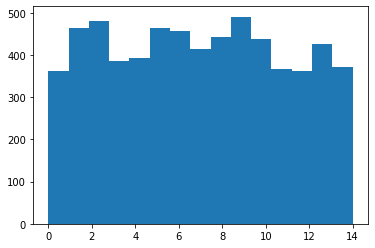

In [79]:
plt.hist([x['paramoji']['selection'] for x in data],15)

In [80]:
np.mean([row['paramoji']['iteration'] > 1.0 for row in data])

0.23560126582278482

In [81]:
df = pd.DataFrame(data)
df['key']=df['url'] + '_' + [str(x) for x in df['X_min']] + '_' + [str(x) for x in df['Y_min']]
result = df.groupby('key').median().reset_index()
result

,key,X_min,X_max,Y_min,Y_max,Width,Height,startTime,endTime,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c
0,http://2.bp.blogspot.com/_Rij1FUW9IOU/TSwLtKCt...,42.0,263.0,3.0,258.0,300.0,300.0,1.644057e+12,1.644057e+12,0.69860,0.41110,0.06410,0.37490,0.0000
1,http://40.media.tumblr.com/c76a8884d4692afc7f5...,91.0,478.0,53.0,504.0,584.0,575.0,1.644057e+12,1.644057e+12,0.59230,0.55785,0.09195,0.54580,0.0000
2,http://4d5166.online-server.cloud//emoticon-da...,0.0,224.0,0.0,224.0,224.0,224.0,1.644057e+12,1.644057e+12,0.78735,0.43070,0.86120,0.51665,0.0000
3,http://4d5166.online-server.cloud//emoticon-da...,0.0,224.0,0.0,224.0,224.0,224.0,1.644057e+12,1.644057e+12,0.77925,0.51250,0.64485,0.63100,0.0000
4,http://4d5166.online-server.cloud//emoticon-da...,0.0,224.0,0.0,224.0,224.0,224.0,1.644057e+12,1.644057e+12,0.78100,0.54085,0.54375,0.57170,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,http://i.dailymail.co.uk/i/pix/2012/11/25/arti...,202.0,299.0,21.0,132.0,634.0,589.0,1.644057e+12,1.644057e+12,0.31350,0.12250,0.49275,0.43815,0.1166
484,http://i.res.24o.it/images2010/Flussi_Input/Da...,156.0,273.0,3.0,141.0,420.0,300.0,1.644057e+12,1.644057e+12,0.59590,0.72765,0.34500,0.54145,0.0000
485,http://i.ytimg.com/vi/4KFQnYhAw8o/0.jpg_147_20,147.0,279.0,20.0,173.0,480.0,360.0,1.644056e+12,1.644056e+12,0.58600,0.14190,0.72010,0.41030,0.0000
486,http://s13.postimage.org/6ohs7qil3/1263059097_...,146.0,230.0,0.0,96.0,300.0,220.0,1.644058e+12,1.644058e+12,0.82410,0.71540,0.12150,0.23530,0.1062


In [82]:
f = open('gen/fec/results.json','w')
f.write(result.to_json(orient='records'))
f.close()

# Published data

In [192]:
# Check faces

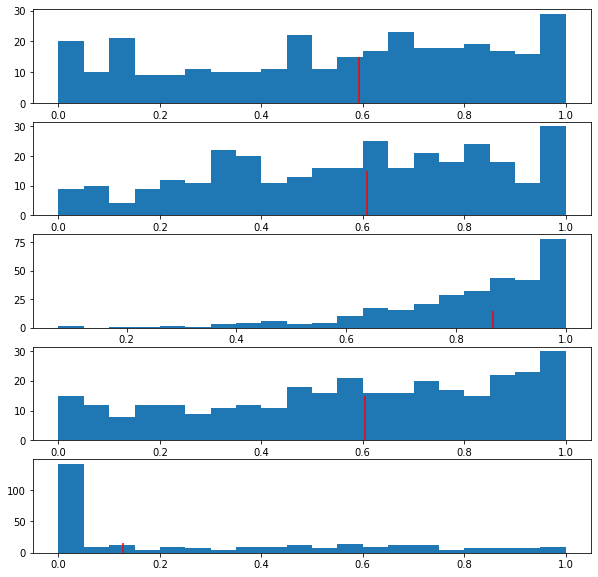

In [84]:
face="triplet_c_2.jpg"
DATA= [row for row in data if face in row['url']]
fig, ax = plt.subplots(5,1, figsize=(10,10))
for i in range(5):
    values = [row['paramoji']['value'][i] for row in DATA]
    ax[i].hist(values,20)
    ax[i].vlines(np.median(values), 0, 15, 'red')